In [963]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.naive_bayes import MultinomialNB
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score, precision_score, recall_score, log_loss, precision_recall_fscore_support, roc_curve, roc_auc_score
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

import statsmodels.api as sm

from imblearn.over_sampling import SMOTE, ADASYN, BorderlineSMOTE


In [964]:
loan_data = pd.read_csv("data/loan_data.csv")
loan_data

,Unnamed: 0,status,loan_amnt,term,annual_inc,dti,payment_inc_ratio,revol_bal,revol_util,purpose,...,delinq_2yrs_zero,pub_rec_zero,open_acc,grade,outcome,emp_length,purpose_,home_,emp_len_,borrower_score
0,1,Charged Off,2500,60 months,30000,1.00,2.39320,1687,9.4,car,...,1,1,3,4.8,default,1,major_purchase,RENT,> 1 Year,0.65
1,2,Charged Off,5600,60 months,40000,5.55,4.57170,5210,32.6,small_business,...,1,1,11,1.4,default,5,small_business,OWN,> 1 Year,0.80
2,3,Charged Off,5375,60 months,15000,18.08,9.71600,9279,36.5,other,...,1,1,2,6.0,default,1,other,RENT,> 1 Year,0.60
3,4,Charged Off,9000,36 months,30000,10.08,12.21520,10452,91.7,debt_consolidation,...,1,1,4,4.2,default,1,debt_consolidation,RENT,> 1 Year,0.50
4,5,Charged Off,10000,36 months,100000,7.06,3.90888,11997,55.5,other,...,1,1,14,5.4,default,4,other,RENT,> 1 Year,0.55
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
45337,45338,Fully Paid,8000,36 months,72000,18.97,4.57850,9725,58.2,credit_card,...,1,0,9,4.2,paid off,8,credit_card,RENT,> 1 Year,0.35
45338,45339,Fully Paid,2000,36 months,25200,13.24,3.20333,4925,40.7,wedding,...,0,1,13,4.2,paid off,3,other,MORTGAGE,> 1 Year,0.50
45339,45340,Fully Paid,4375,36 months,20000,7.95,9.98460,6574,73.0,debt_consolidation,...,1,1,8,2.4,paid off,1,debt_consolidation,MORTGAGE,> 1 Year,0.55
45340,45341,Fully Paid,8000,36 months,48000,26.91,6.45250,10303,32.4,debt_consolidation,...,1,1,10,5.2,paid off,1,debt_consolidation,MORTGAGE,> 1 Year,0.65


In [965]:
loan_data.outcome.value_counts()

outcome
default     22671
paid off    22671
Name: count, dtype: int64

In [966]:
loan_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45342 entries, 0 to 45341
Data columns (total 21 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Unnamed: 0         45342 non-null  int64  
 1   status             45342 non-null  object 
 2   loan_amnt          45342 non-null  int64  
 3   term               45342 non-null  object 
 4   annual_inc         45342 non-null  int64  
 5   dti                45342 non-null  float64
 6   payment_inc_ratio  45342 non-null  float64
 7   revol_bal          45342 non-null  int64  
 8   revol_util         45342 non-null  float64
 9   purpose            45342 non-null  object 
 10  home_ownership     45342 non-null  object 
 11  delinq_2yrs_zero   45342 non-null  int64  
 12  pub_rec_zero       45342 non-null  int64  
 13  open_acc           45342 non-null  int64  
 14  grade              45342 non-null  float64
 15  outcome            45342 non-null  object 
 16  emp_length         453

In [967]:
loan_data.outcome = loan_data.outcome.astype('category')
loan_data.outcome.cat.reorder_categories(['paid off', 'default'])
loan_data.purpose_ = loan_data.purpose_.astype('category')
loan_data.home_ = loan_data.home_.astype('category')
loan_data.emp_len_ = loan_data.emp_len_.astype('category')

def print_metrics(y_true,y_pred):
    print(f"Accuracy: {accuracy_score(y_true,y_pred)}")
    print(f"Precision: {precision_score(y_true,y_pred)}")
    print(f"Recall: {recall_score(y_true,y_pred)}")
    print(f"Logloss: {log_loss(y_true,y_pred)}")

In [968]:
loan_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45342 entries, 0 to 45341
Data columns (total 21 columns):
 #   Column             Non-Null Count  Dtype   
---  ------             --------------  -----   
 0   Unnamed: 0         45342 non-null  int64   
 1   status             45342 non-null  object  
 2   loan_amnt          45342 non-null  int64   
 3   term               45342 non-null  object  
 4   annual_inc         45342 non-null  int64   
 5   dti                45342 non-null  float64 
 6   payment_inc_ratio  45342 non-null  float64 
 7   revol_bal          45342 non-null  int64   
 8   revol_util         45342 non-null  float64 
 9   purpose            45342 non-null  object  
 10  home_ownership     45342 non-null  object  
 11  delinq_2yrs_zero   45342 non-null  int64   
 12  pub_rec_zero       45342 non-null  int64   
 13  open_acc           45342 non-null  int64   
 14  grade              45342 non-null  float64 
 15  outcome            45342 non-null  category
 16  emp_

In [969]:
predictors = ['purpose_', 'home_', 'emp_len_']
outcome = 'outcome'

X = pd.get_dummies(loan_data[predictors], prefix="", prefix_sep="")
y = loan_data[outcome]

X_train,X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

naive_model = MultinomialNB(alpha=0.01, fit_prior=True)
naive_model.fit(X_train, y_train)

,alpha,0.01
,force_alpha,True
,fit_prior,True
,class_prior,None


In [970]:
naive_model.predict_proba(X_test)

array([[0.47464442, 0.52535558],
       [0.50322293, 0.49677707],
       [0.53682842, 0.46317158],
       ...,
       [0.5568676 , 0.4431324 ],
       [0.53682842, 0.46317158],
       [0.53682842, 0.46317158]], shape=(9069, 2))

In [971]:
probabilities = pd.DataFrame(naive_model.predict_proba(X_test.loc[[19058], :]),
columns=loan_data[outcome].cat.categories)

In [972]:
loan3000 = pd.read_csv("data/loan3000.csv")
loan3000.head()

,Unnamed: 0,outcome,purpose_,dti,borrower_score,payment_inc_ratio
0,32109,paid off,debt_consolidation,21.23,0.40,5.11135
1,16982,default,credit_card,15.49,0.40,5.43165
2,25335,paid off,debt_consolidation,27.30,0.70,9.23003
3,34580,paid off,major_purchase,21.11,0.40,2.33482
4,14424,default,debt_consolidation,16.46,0.45,12.10320


In [973]:
loan3000.outcome = loan3000.outcome.astype("category")

predictors = ['borrower_score', 'payment_inc_ratio']
outcome = "outcome"

X = loan3000[predictors]
y = loan3000[outcome]

loan_lda = LinearDiscriminantAnalysis()
loan_lda.fit(X, y)

pd.DataFrame(loan_lda.scalings_, index=X.columns)

,0
borrower_score,7.175839
payment_inc_ratio,-0.099676


In [974]:
pred = pd.DataFrame(loan_lda.predict_proba(loan3000[predictors]),
                    columns=loan_lda.classes_)
print(pred.head())

    default  paid off
0  0.553544  0.446456
1  0.558953  0.441047
2  0.272696  0.727304
3  0.506254  0.493746
4  0.609952  0.390048


In [975]:
# Use scalings and center of means to determine decision boundary
center = np.mean(loan_lda.means_, axis=0)
slope = - loan_lda.scalings_[0] / loan_lda.scalings_[1]
intercept = center[1] - center[0] * slope

# payment_inc_ratio for borrower_score of 0 and 20
x_0 = (0 - intercept) / slope
x_20 = (20 - intercept) / slope

lda_df = pd.concat([loan3000, pred['default']], axis=1)
lda_df.head()


,Unnamed: 0,outcome,purpose_,dti,borrower_score,payment_inc_ratio,default
0,32109,paid off,debt_consolidation,21.23,0.40,5.11135,0.553544
1,16982,default,credit_card,15.49,0.40,5.43165,0.558953
2,25335,paid off,debt_consolidation,27.30,0.70,9.23003,0.272696
3,34580,paid off,major_purchase,21.11,0.40,2.33482,0.506254
4,14424,default,debt_consolidation,16.46,0.45,12.10320,0.609952


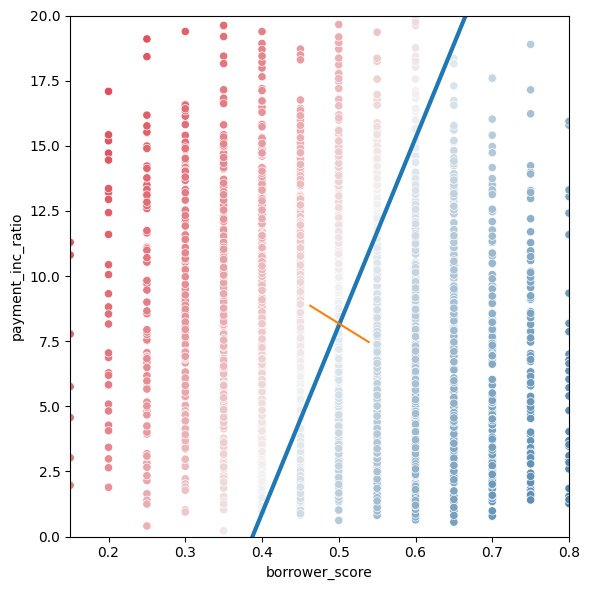

In [976]:

fig, ax = plt.subplots(figsize=(6, 6))
g = sns.scatterplot(x='borrower_score', y='payment_inc_ratio',
                    hue='default', data=lda_df, 
                    palette=sns.diverging_palette(240, 10, n=9, as_cmap=True),
                    ax=ax, legend=False)

ax.set_ylim(0, 20)
ax.set_xlim(0.15, 0.8)
ax.plot((x_0, x_20), (0, 20), linewidth=3)
ax.plot(*loan_lda.means_.transpose())

plt.tight_layout()
plt.show()

In [977]:
predictors = ['payment_inc_ratio', 'purpose_', 'home_', 'emp_len_','borrower_score']
outcome = 'outcome'

X = pd.get_dummies(loan_data[predictors], prefix='', prefix_sep='', drop_first=True)
y = [1 if outc == "paid off" else 0 for outc in loan_data[outcome]]

X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42, test_size=0.2)

logit_reg = LogisticRegression(penalty='l2', C=1e42, solver='liblinear')
logit_reg.fit(X_train, y_train)


,penalty,'l2'
,dual,False
,tol,0.0001
,C,1e+42
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'liblinear'
,max_iter,100
,multi_class,'deprecated'


In [978]:
y_test_pred = logit_reg.predict(X_test)

print_metrics(y_test, y_test_pred)

Accuracy: 0.6453853787628184
Precision: 0.6458470304624151
Recall: 0.6481196393226303
Logloss: 12.781606494586036


In [979]:
pred = pd.DataFrame(logit_reg.predict_log_proba(X), columns=loan_data[outcome].cat.categories)
pred.describe()

,default,paid off
count,45342.000000,45342.000000
mean,-0.755618,-0.758515
std,0.371682,0.383429
min,-2.718506,-3.475368
25%,-0.980237,-0.971559
50%,-0.697293,-0.689018
75%,-0.475607,-0.470359
max,-0.031440,-0.068250


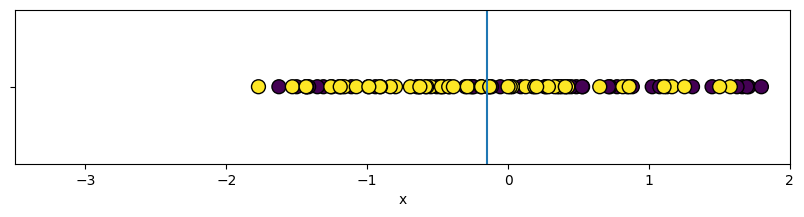

In [980]:
def print_graph(num1):
    X = np.append(loan_data.payment_inc_ratio.values[:num1], loan_data.payment_inc_ratio.values[40000:40000 + num1])

    scalar = StandardScaler()
    X = scalar.fit_transform(X.reshape(-1,1))

    y = [1 if outc == "paid off" else 0 for outc in np.append(loan_data.outcome.values[:num1], loan_data.outcome.values[40000:40000 + num1])]

    plt.figure(figsize=(10, 2))
    plt.scatter(X, np.zeros(X.shape[0]), c=y, s=100, edgecolors='black')
    plt.plot([-0.15, -0.15], [-1, 1])
    plt.ylabel('');plt.xlabel('x')
    plt.yticks(np.arange(0, 1), [''])
    plt.ylim(-1, 1);plt.xlim(-3.5, 2);

print_graph(50)

In [981]:
X = loan_data.payment_inc_ratio.values.reshape(-1,1)
y = [1 if outc == "paid off" else 0 for outc in loan_data.outcome]

scalar = StandardScaler()
X = scalar.fit_transform(X)

logit_reg = LogisticRegression()
logit_reg.fit(X,y)

# (array([0.66921348]), array([[-0.08355229]]))

logit_reg.intercept_ , logit_reg.coef_

(array([-0.00187195]), array([[-0.35603577]]))

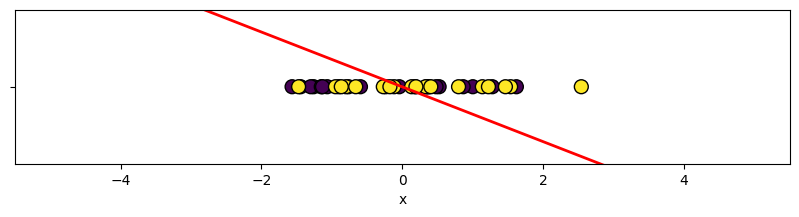

In [982]:
x = np.linspace(-5, 5)
model_y_sk = logit_reg.coef_[0][0] * x + logit_reg.intercept_[0]

num1 = 20

X_test = np.append(loan_data.payment_inc_ratio.values[:num1], loan_data.payment_inc_ratio.values[40000:40000 + num1]).reshape(-1,1)

X_test = scalar.fit_transform(X_test)

y_test = [1 if outc == "paid off" else 0 for outc in np.append(loan_data.outcome.values[:num1], loan_data.outcome.values[40000:40000 + num1])]



plt.figure(figsize=(10, 2))
plt.plot(x, model_y_sk, linewidth=2, c='r')
plt.scatter(X_test, np.zeros(X_test.shape[0]), c=y_test, s=100, edgecolors='black')
plt.ylabel('');plt.xlabel('x')
plt.yticks(np.arange(0, 1), [''])
plt.ylim(-1, 1);

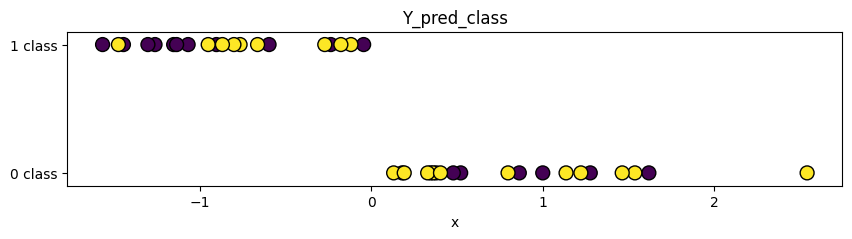

In [983]:
y_pred_cl = logit_reg.predict(X_test)

plt.figure(figsize=(10, 2))
plt.scatter(X_test, y_pred_cl, c=y_test, s=100, edgecolors='black')
plt.ylabel('');plt.xlabel('x')
plt.yticks(np.arange(0, 2), ['0 class', '1 class'])
plt.ylim(-0.1, 1.1)
plt.title('Y_pred_class');

In [984]:

print_metrics(y_test, y_pred_cl)

Accuracy: 0.45
Precision: 0.45
Recall: 0.45
Logloss: 19.824009364014433


In [985]:
predictors = ['payment_inc_ratio', 'purpose_', 'home_', 'emp_len_', 
              'borrower_score']
outcome = 'outcome'
X = pd.get_dummies(loan_data[predictors], prefix_sep='', 
                   drop_first=True, dtype=int)
y = loan_data[outcome] # .cat.categories

logit_reg = LogisticRegression(penalty='l2', C=1e42, solver='liblinear')
logit_reg.fit(X, y)

print('intercept ', logit_reg.intercept_[0])
print('classes', logit_reg.classes_)
pd.DataFrame({'coeff': logit_reg.coef_[0]}, 
             index=X.columns)

intercept  -1.6378907921853014
classes ['default' 'paid off']


,coeff
payment_inc_ratio,-0.079739
borrower_score,4.612183
purpose_debt_consolidation,-0.249414
purpose_home_improvement,-0.407734
purpose_major_purchase,-0.229710
purpose_medical,-0.510744
purpose_other,-0.620800
purpose_small_business,-1.214936
home_OWN,-0.048211
home_RENT,-0.157288


In [986]:
print(loan_data['purpose_'].cat.categories)
print(loan_data['home_'].cat.categories)
print(loan_data['emp_len_'].cat.categories)

Index(['credit_card', 'debt_consolidation', 'home_improvement',
       'major_purchase', 'medical', 'other', 'small_business'],
      dtype='object')
Index(['MORTGAGE', 'OWN', 'RENT'], dtype='object')
Index([' < 1 Year', ' > 1 Year'], dtype='object')


In [987]:
from sklearn.preprocessing import OrdinalEncoder
enc = OrdinalEncoder(categories=[['paid off','default']])
y_enc = enc.fit_transform(loan_data[[outcome]]).ravel()

logit_reg_enc = LogisticRegression(penalty="l2", C=1e42, solver='liblinear')
logit_reg_enc.fit(X, y_enc)

print('intercept ', logit_reg_enc.intercept_[0])
print('classes', logit_reg_enc.classes_)
pd.DataFrame({'coeff': logit_reg_enc.coef_[0]}, 
             index=X.columns)

intercept  1.637890823185279
classes [0. 1.]


,coeff
payment_inc_ratio,0.079739
borrower_score,-4.612183
purpose_debt_consolidation,0.249414
purpose_home_improvement,0.407734
purpose_major_purchase,0.229710
purpose_medical,0.510744
purpose_other,0.620800
purpose_small_business,1.214936
home_OWN,0.048211
home_RENT,0.157288


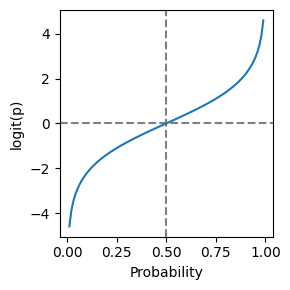

In [988]:
p = np.arange(0.01, 1, 0.01)
df = pd.DataFrame({
    'p': p,
    'logit': np.log(p / (1 - p)),
    'odds': p / (1 - p),
})

fig, ax = plt.subplots(figsize=(3, 3))
ax.axhline(0, color='grey', linestyle='--')
ax.axvline(0.5, color='grey', linestyle='--')
ax.plot(df['p'], df['logit'])
ax.set_xlabel('Probability')
ax.set_ylabel('logit(p)')

plt.tight_layout()
plt.show()


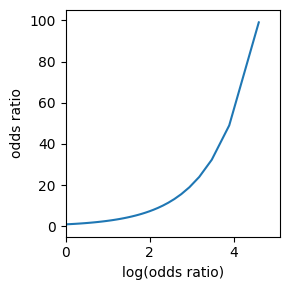

In [989]:
fig, ax = plt.subplots(figsize=(3, 3))
ax.plot(df['logit'], df['odds'])
ax.set_xlabel('log(odds ratio)')
ax.set_ylabel('odds ratio')
ax.set_xlim(0, 5.1)
ax.set_ylim(-5, 105)

plt.tight_layout()
plt.show()

In [990]:
df

,p,logit,odds
0,0.01,-4.595120,0.010101
1,0.02,-3.891820,0.020408
2,0.03,-3.476099,0.030928
3,0.04,-3.178054,0.041667
4,0.05,-2.944439,0.052632
...,...,...,...
94,0.95,2.944439,19.000000
95,0.96,3.178054,24.000000
96,0.97,3.476099,32.333333
97,0.98,3.891820,49.000000


In [991]:
y_numbers = [1 if yi == 'default' else 0 for yi in y]
logit_reg_sm = sm.GLM(y_numbers, X.assign(const=1),
family=sm.families.Binomial())
logit_result = logit_reg_sm.fit()
logit_result.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                 Generalized Linear Model Regression Results                  
==============================================================================
Dep. Variable:                      y   No. Observations:                45342
Model:                            GLM   Df Residuals:                    45330
Model Family:                Binomial   Df Model:                           11
Link Function:                  Logit   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -28757.
Date:                Mon, 29 Sep 2025   Deviance:                       57515.
Time:                        18:58:11   Pearson chi2:                 4.54e+04
No. Iterations:                     4   Pseudo R-squ. (CS):             0.1112
Covariance Type:            nonrobust                                         
==============================================================================================
                                 coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------------
payment_inc_ratio              0.0797      0.002     32.058      0.000       0.075       0.085
borrower_score                -4.6126      0.084    -55.203      0.000      -4.776      -4.449
purpose_debt_consolidation     0.2494      0.028      9.030      0.000       0.195       0.303
purpose_home_improvement       0.4077      0.047      8.747      0.000       0.316       0.499
purpose_major_purchase         0.2296      0.054      4.277      0.000       0.124       0.335
purpose_medical                0.5105      0.087      5.882      0.000       0.340       0.681
purpose_other                  0.6207      0.039     15.738      0.000       0.543       0.698
purpose_small_business         1.2153      0.063     19.192      0.000       1.091       1.339
home_OWN                       0.0483      0.038      1.271      0.204      -0.026       0.123
home_RENT                      0.1573      0.021      7.420      0.000       0.116       0.199
emp_len_ > 1 Year             -0.3567      0.053     -6.779      0.000      -0.460      -0.254
const                          1.6381      0.074     22.224      0.000       1.494       1.783
==============================================================================================
"""

In [992]:
import statsmodels.formula.api as smf
formula = ('outcome ~ bs(payment_inc_ratio, df=4) + purpose_ + ' +
'home_ + emp_len_ + bs(borrower_score, df=4)')
model = smf.glm(formula=formula, data=loan_data, family=sm.families.Binomial())
results = model.fit()
results.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                             Generalized Linear Model Regression Results                             
=====================================================================================================
Dep. Variable:     ['outcome[default]', 'outcome[paid off]']   No. Observations:                45342
Model:                                                   GLM   Df Residuals:                    45324
Model Family:                                       Binomial   Df Model:                           17
Link Function:                                         Logit   Scale:                          1.0000
Method:                                                 IRLS   Log-Likelihood:                -28744.
Date:                                       Mon, 29 Sep 2025   Deviance:                       57487.
Time:                                               18:58:11   Pearson chi2:                 4.54e+04
No. Iterations:                                            5   Pseudo R-squ. (CS):             0.1117
Covariance Type:                                   nonrobust                                         
==================================================================================================
                                     coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------------------
Intercept                          1.8382      0.380      4.836      0.000       1.093       2.583
purpose_[T.debt_consolidation]     0.2491      0.028      9.020      0.000       0.195       0.303
purpose_[T.home_improvement]       0.4138      0.047      8.848      0.000       0.322       0.505
purpose_[T.major_purchase]         0.2401      0.054      4.450      0.000       0.134       0.346
purpose_[T.medical]                0.5183      0.087      5.953      0.000       0.348       0.689
purpose_[T.other]                  0.6295      0.040     15.812      0.000       0.552       0.708
purpose_[T.small_business]         1.2252      0.063     19.303      0.000       1.101       1.350
home_[T.OWN]                       0.0484      0.038      1.273      0.203      -0.026       0.123
home_[T.RENT]                      0.1581      0.021      7.456      0.000       0.117       0.200
emp_len_[T. > 1 Year]             -0.3541      0.053     -6.729      0.000      -0.457      -0.251
bs(payment_inc_ratio, df=4)[0]     0.0049      0.121      0.041      0.967      -0.232       0.241
bs(payment_inc_ratio, df=4)[1]     1.6033      0.142     11.289      0.000       1.325       1.882
bs(payment_inc_ratio, df=4)[2]     1.9033      0.488      3.900      0.000       0.947       2.860
bs(payment_inc_ratio, df=4)[3]    -0.8521      1.929     -0.442      0.659      -4.633       2.929
bs(borrower_score, df=4)[0]       -1.0045      0.476     -2.112      0.035      -1.937      -0.072
bs(borrower_score, df=4)[1]       -2.6411      0.287     -9.209      0.000      -3.203      -2.079
bs(borrower_score, df=4)[2]       -3.6984      0.473     -7.824      0.000      -4.625      -2.772
bs(borrower_score, df=4)[3]       -5.8564      0.525    -11.160      0.000      -6.885      -4.828
==================================================================================================
"""

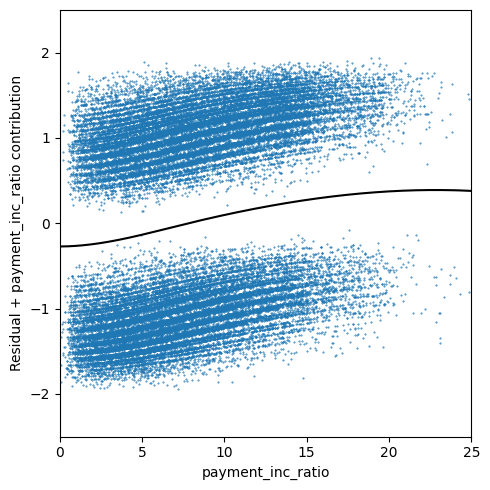

In [993]:
from statsmodels.genmod.generalized_linear_model import GLMResults
def partialResidualPlot(model, df, outcome, feature, fig, ax):
    y_actual = [0 if s == 'default' else 1 for s in df[outcome]]
    y_pred = model.predict(df)
    org_params = model.params.copy()
    zero_params = model.params.copy()
    # set model parametes of other features to 0
    for i, name in enumerate(zero_params.index):
        if feature in name:
            continue
        zero_params.iloc[i] = 0.0
    model.initialize(model.model, zero_params)
    feature_prediction = model.predict(df)
    ypartial = -np.log(1/feature_prediction - 1)
    ypartial = ypartial - np.mean(ypartial)
    model.initialize(model.model, org_params)
    results = pd.DataFrame({
        'feature': df[feature],
        'residual': -2 * (y_actual - y_pred),
        'ypartial': ypartial/ 2,
    })
    results = results.sort_values(by=['feature'])

    ax.scatter(results.feature, results.residual, marker=".", s=72./fig.dpi)
    ax.plot(results.feature, results.ypartial, color='black')
    ax.set_xlabel(feature)
    ax.set_ylabel(f'Residual + {feature} contribution')
    return ax

fig, ax = plt.subplots(figsize=(5, 5))
partialResidualPlot(results, loan_data, 'outcome', 'payment_inc_ratio', fig, ax)
ax.set_xlim(0, 25)
ax.set_ylim(-2.5, 2.5)


plt.tight_layout()
plt.show()

In [994]:
# Confusion matrix
pred = logit_reg.predict(X)
pred_y = logit_reg.predict(X) == 'default'
true_y = y == 'default'
true_pos = true_y & pred_y
true_neg = ~true_y & ~pred_y
false_pos = ~true_y & pred_y
false_neg = true_y & ~pred_y

conf_mat = pd.DataFrame([[np.sum(true_pos), np.sum(false_pos)],
                        [np.sum(false_neg), np.sum(true_neg)]],
                       index=['pred pos', 'pred neg'],
                       columns=['actual pos', 'actual neg'])
print(conf_mat)

          actual pos  actual neg
pred pos       14337        8149
pred neg        8334       14522


In [995]:
print(confusion_matrix(y, logit_reg.predict(X)))

[[14337  8334]
 [ 8149 14522]]


In [996]:
conf_mat = confusion_matrix(y, logit_reg.predict(X))
print('Precision', conf_mat[0, 0] / sum(conf_mat[:, 0]))
print('Recall', conf_mat[0, 0] / sum(conf_mat[0, :]))
print('Specificity', conf_mat[1, 1] / sum(conf_mat[1, :]))

Precision 0.6375967268522637
Recall 0.6323938070662961
Specificity 0.640554011733051


In [997]:
precision_recall_fscore_support(y, logit_reg.predict(X), 
                                labels=['default', 'paid off'])

(array([0.63759673, 0.63536927]),
 array([0.63239381, 0.64055401]),
 array([0.63498461, 0.63795111]),
 array([22671, 22671]))

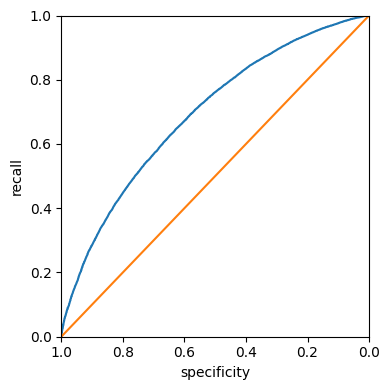

In [998]:
fpr, tpr, thresholds = roc_curve(y, logit_reg.predict_proba(X)[:, 0], 
                                 pos_label='default')
roc_df = pd.DataFrame({'recall': tpr, 'specificity': 1 - fpr})

ax = roc_df.plot(x='specificity', y='recall', figsize=(4, 4), legend=False)
ax.set_ylim(0, 1)
ax.set_xlim(1, 0)
ax.plot((1, 0), (0, 1))
ax.set_xlabel('specificity')
ax.set_ylabel('recall')


plt.tight_layout()
plt.show()


In [999]:
print(np.sum(roc_df.recall[:-1] * np.diff(1 - roc_df.specificity)))
print(roc_auc_score([1 if yi == 'default' else 0 for yi in y], logit_reg.predict_proba(X)[:, 0]))

0.6917107135725116
0.6917107913974234


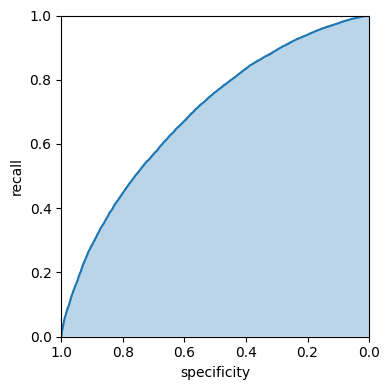

In [1000]:
fpr, tpr, thresholds = roc_curve(y, logit_reg.predict_proba(X)[:,0], 
                                 pos_label='default')
roc_df = pd.DataFrame({'recall': tpr, 'specificity': 1 - fpr})

ax = roc_df.plot(x='specificity', y='recall', figsize=(4, 4), legend=False)
ax.set_ylim(0, 1)
ax.set_xlim(1, 0)
# ax.plot((1, 0), (0, 1))
ax.set_xlabel('specificity')
ax.set_ylabel('recall')
ax.fill_between(roc_df.specificity, 0, roc_df.recall, alpha=0.3)


plt.tight_layout()
plt.show()

In [1001]:
loan3000.outcome.value_counts()

outcome
paid off    1555
default     1445
Name: count, dtype: int64

In [1002]:
loan_data.outcome.value_counts()

outcome
default     22671
paid off    22671
Name: count, dtype: int64

In [1003]:
full_train_set = pd.read_csv("data/full_train_set.csv")
full_train_set

,status,loan_amnt,term,annual_inc,dti,payment_inc_ratio,revol_bal,revol_util,purpose,home_ownership,delinq_2yrs_zero,pub_rec_zero,open_acc,grade,outcome,emp_length,purpose_,home_,emp_len_
0,Fully Paid,5000,36 months,24000,27.65,8.14350,13648.0,83.7,credit_card,RENT,1,1,3,5.4,paid off,11,credit_card,RENT,> 1 Year
1,Charged Off,2500,60 months,30000,1.00,2.39320,1687.0,9.4,car,RENT,1,1,3,4.8,default,1,major_purchase,RENT,> 1 Year
2,Fully Paid,2400,36 months,12252,8.72,8.25955,2956.0,98.5,small_business,RENT,1,1,2,5.0,paid off,11,small_business,RENT,> 1 Year
3,Fully Paid,10000,36 months,49200,20.00,8.27585,5598.0,21.0,other,RENT,1,1,10,4.2,paid off,11,other,RENT,> 1 Year
4,Fully Paid,5000,36 months,36000,11.20,5.21533,7963.0,28.3,wedding,RENT,1,1,9,6.8,paid off,4,other,RENT,> 1 Year
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
119982,Fully Paid,7000,36 months,46200,30.05,6.11325,6835.0,43.0,debt_consolidation,MORTGAGE,1,1,12,5.8,paid off,11,debt_consolidation,MORTGAGE,> 1 Year
119983,Fully Paid,21000,60 months,91800,8.04,6.82092,12187.0,23.9,medical,RENT,1,1,14,3.2,paid off,3,medical,RENT,> 1 Year
119984,Fully Paid,28775,60 months,60000,13.72,15.40780,16542.0,78.4,home_improvement,MORTGAGE,1,0,14,2.2,paid off,11,home_improvement,MORTGAGE,> 1 Year
119985,Fully Paid,6000,36 months,57500,23.61,4.25113,5188.0,31.6,debt_consolidation,RENT,0,1,12,6.0,paid off,4,debt_consolidation,RENT,> 1 Year


In [1004]:
full_train_set.outcome.value_counts()

outcome
paid off    97316
default     22671
Name: count, dtype: int64

In [1005]:
print('percentage of loans in default: ',
100 * np.mean(full_train_set.outcome == 'default'))

percentage of loans in default:  18.894546909248504


In [1006]:
predictors = ['payment_inc_ratio', 'purpose_', 'home_', 'emp_len_', 
              'dti', 'revol_bal', 'revol_util']
outcome = 'outcome'
X = pd.get_dummies(full_train_set[predictors], prefix='', prefix_sep='', 
                   drop_first=True, dtype=int)
y = full_train_set[outcome]

full_model = LogisticRegression(penalty='l2', C=1e42, solver='liblinear')
full_model.fit(X, y)
print('percentage of loans predicted to default: ', print(100 * np.mean(full_model.predict(X) == 'default')))

1.0134431230049923
percentage of loans predicted to default:  None


In [1007]:
predictors = ['payment_inc_ratio', 'purpose_', 'home_', 'emp_len_', 
              'dti', 'revol_bal', 'revol_util']
outcome = 'outcome'
X = pd.get_dummies(loan_data[predictors], prefix='', prefix_sep='', 
                   drop_first=True, dtype=int)
y = loan_data[outcome]


enc = OrdinalEncoder(categories=[['paid off','default']])
y_enc = enc.fit_transform(y.values.reshape(-1,1)).ravel()

model_main = LogisticRegression(penalty='l2', C=1e42, solver='liblinear')
model_main.fit(X, y_enc)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1e+42
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'liblinear'
,max_iter,100
,multi_class,'deprecated'


In [1008]:
print_metrics(y_enc, model_main.predict(X))

Accuracy: 0.6086189404966698
Precision: 0.6101247708063146
Recall: 0.6017820122623616
Logloss: 14.10680325180347


In [1009]:
print_metrics(y_enc, [1 if i == "default" else 0 for i in full_model.predict(X)])

Accuracy: 0.5056900886595209
Precision: 0.6996904024767802
Recall: 0.019937364915530855
Logloss: 17.81673511116145


In [1010]:
y_enc

array([1., 1., 1., ..., 0., 0., 0.], shape=(45342,))

In [1011]:
model_main.predict(X)

array([0., 1., 1., ..., 0., 0., 1.], shape=(45342,))

In [1012]:
pd.Series(full_model.predict(X)).value_counts()

paid off    44696
default       646
Name: count, dtype: int64

In [1013]:
pd.Series(model_main.predict(X)).value_counts()

0.0    22981
1.0    22361
Name: count, dtype: int64

In [1014]:
predictors = ['payment_inc_ratio', 'purpose_', 'home_', 'emp_len_', 
              'dti', 'revol_bal', 'revol_util']
outcome = 'outcome'
X = pd.get_dummies(full_train_set[predictors], prefix='', prefix_sep='', 
                   drop_first=True, dtype=int)
y = full_train_set[outcome]


default_wt = 1 / np.mean(full_train_set.outcome == 'default')
wt = [default_wt if outcome == 'default' else 1 for outcome in full_train_set.outcome]

enc = OrdinalEncoder(categories=[['paid off','default']])
y_enc = enc.fit_transform(y.values.reshape(-1,1)).ravel()

model_full2 = LogisticRegression(penalty="l2", C=1e42, solver='liblinear')
model_full2.fit(X, y, sample_weight=wt)


print('percentage of loans predicted to default (weighting): ',
100 * np.mean(model_full2.predict(X) == 'default'))



print_metrics(y_enc, enc.fit_transform(model_full2.predict(X).reshape(-1,1)).ravel())


percentage of loans predicted to default (weighting):  62.350087926191996
Accuracy: 0.4798519839649295
Precision: 0.2344008982516174
Recall: 0.7734991839795333
Logloss: 18.748034801005026


In [ ]:
X_resampled, y_resampled = SMOTE().fit_resample(X, y)
print('percentage of loans in default (SMOTE resampled): ', 
      100 * np.mean(y_resampled == 'default'))

full_model = LogisticRegression(penalty="l2", C=1e42, solver='liblinear')
full_model.fit(X_resampled, y_resampled)
print('percentage of loans predicted to default (SMOTE): ', 
      100 * np.mean(full_model.predict(X) == 'default'))

print_metrics([1 if i == "default" else 0 for i in y_resampled], [1 if i == "default" else 0 for i in full_model.predict(X_resampled)])


X_resampled, y_resampled = ADASYN().fit_resample(X, y)
print('percentage of loans in default (ADASYN resampled): ', 
      100 * np.mean(y_resampled == 'default'))

full_model = LogisticRegression(penalty="l2", C=1e42, solver='liblinear')
full_model.fit(X_resampled, y_resampled)

print_metrics([1 if i == "default" else 0 for i in y_resampled], [1 if i == "default" else 0 for i in full_model.predict(X_resampled)])
print('percentage of loans predicted to default (ADASYN): ', 
print(      100 * np.mean(full_model.predict(X) == 'default')))

percentage of loans in default (SMOTE resampled):  50.0
percentage of loans predicted to default (SMOTE):  29.34817938610016
Accuracy: 0.6997153602696371
Precision: 0.7071683632681341
Recall: 0.6817275679230548
Logloss: 10.823355472517118
percentage of loans in default (ADASYN resampled):  48.56040383751355
27.958028786451866
percentage of loans predicted to default (ADASYN):  None
